In [6]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv("heart_disease_uci.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst Rows:\n", df.head())

# =========================
# 3. DATA INSPECTION
# =========================
print("\nInfo:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# =========================
# 4. DATA CLEANING
# =========================

# Fill missing values (if any)
df = df.fillna(df.median(numeric_only=True))

# =========================
# 5. TARGET VARIABLE
# =========================
# Usually target column is named 'target' or 'num'
# Adjust if needed
if 'target' in df.columns:
    target_col = 'target'
elif 'num' in df.columns:
    target_col = 'num'
else:
    raise Exception("Target column not found!")

# Convert target to binary (0 = no disease, 1 = disease)
df[target_col] = df[target_col].apply(lambda x: 1 if x > 0 else 0)


Shape: (920, 16)

Columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

First Rows:
    id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0 

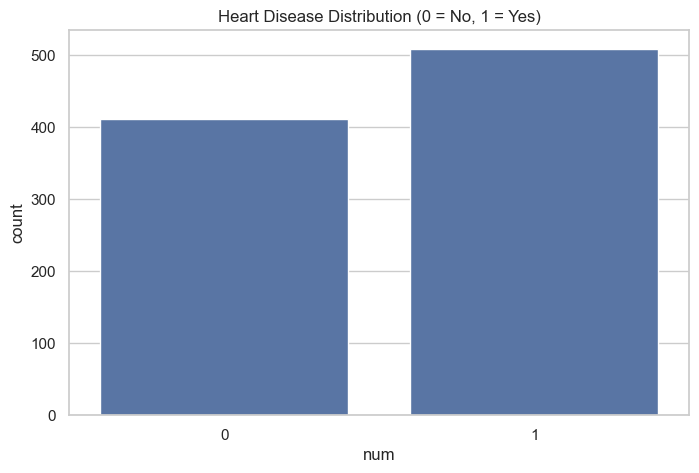

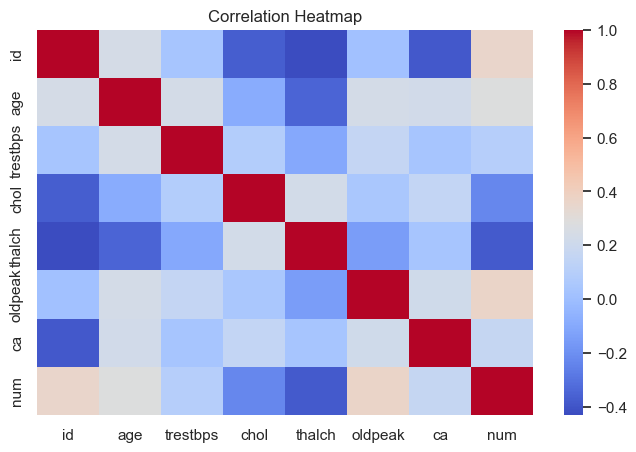

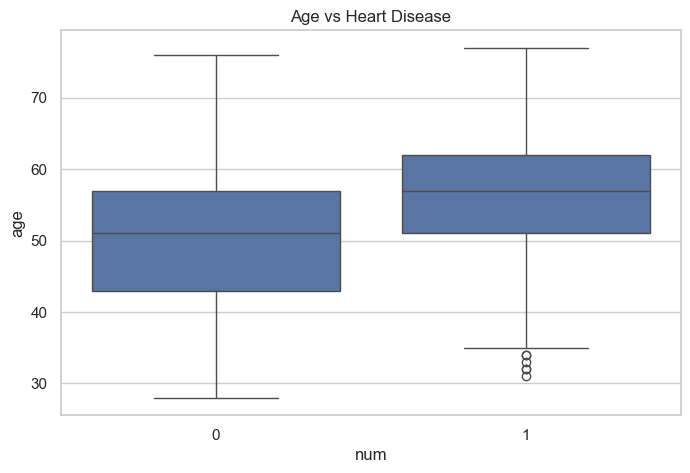

In [7]:

# =========================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# =========================

# Target distribution
sns.countplot(x=df[target_col])
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Example feature analysis
sns.boxplot(x=target_col, y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

# =========================
# 7. FEATURE & TARGET SPLIT
# =========================
X = df.drop(columns=[target_col])
y = df[target_col]

# =========================
# 8. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Logistic Regression Accuracy: 0.842391304347826
Decision Tree Accuracy: 0.8206521739130435


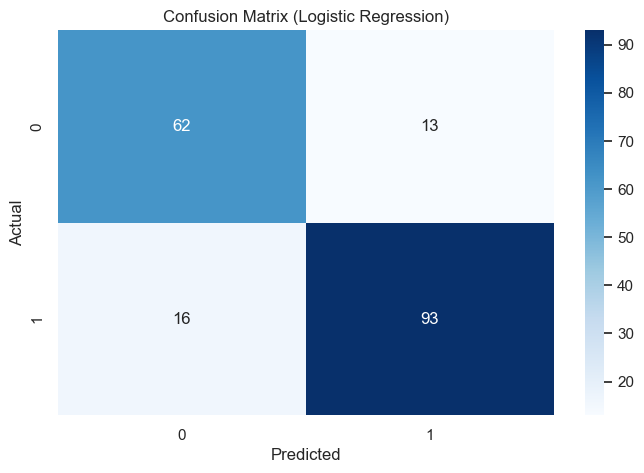


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        75
           1       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [11]:
# =========================
# 7. FEATURE & TARGET SPLIT
# =========================
X = df.drop(columns=[target_col])
y = df[target_col]

# =========================
# 8. ENCODE CATEGORICAL FEATURES
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# 9. TRAIN-TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 10. FEATURE SCALING
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# Transform test data (no fit)
X_test = scaler.transform(X_test)

# =========================
# 11. MODEL TRAINING
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)  # avoid convergence issues
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# =========================
# 12. PREDICTIONS
# =========================
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

# =========================
# 13. EVALUATION
# =========================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

# Confusion Matrix (Logistic Regression)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, lr_pred))

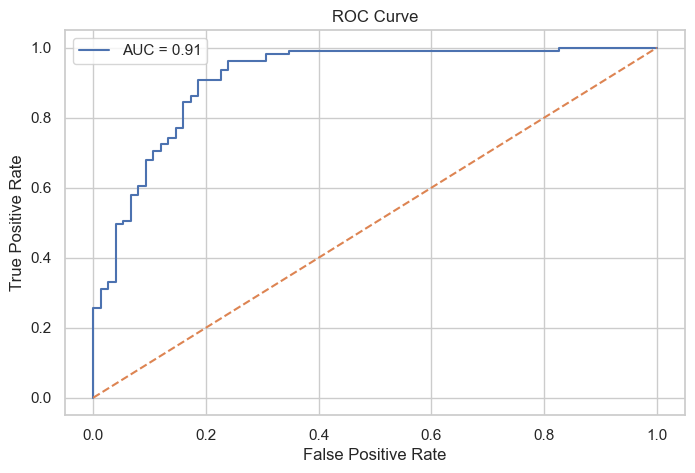

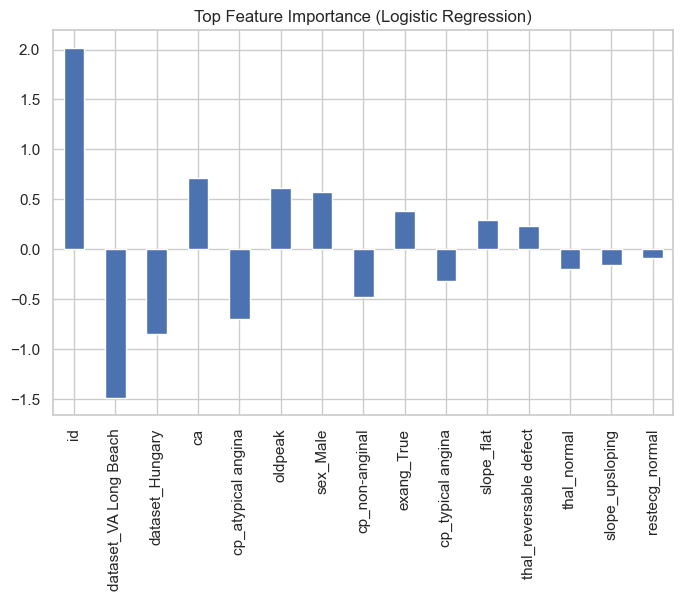

In [13]:

# =========================
# 13. ROC CURVE
# =========================
lr_probs = lr_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = roc_auc_score(y_test, lr_probs)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# =========================
# 14. FEATURE IMPORTANCE (LOGISTIC REGRESSION)
# =========================
importance = pd.Series(lr_model.coef_[0], index=X.columns)
importance = importance.sort_values(key=abs, ascending=False)

importance.head(15).plot(kind="bar")
plt.title("Top Feature Importance (Logistic Regression)")
plt.show()